# Anhedonic AI — Analysis
**Model A:** Qwen2-VL-7B | Layers 18–27 ablated | ~1,363 neurons | 0.257% of network

| Experiment | Design | N subjects | Purpose |
|---|---|---|---|
| **Exp 1** | Choose 1 of 4 questions, reward labels visible | 57 | Main — anhedonic behaviour |
| **Exp 3** | Single question, standard MMLU, no reward | 57 | Sanity check — knowledge intact |

**Statistics:** Paired t-tests (one-tailed H₁: Model A < Baseline), 95% CI, BH-corrected per-subject tests, K=5 fold error bars (std across subsets).

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
from scipy import stats as sp_stats
from statsmodels.stats.multitest import multipletests
import warnings, os
from glob import glob
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130, 'font.family': 'sans-serif',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.2, 'grid.linewidth': 0.5,
})
BL = '#2563EB'   # baseline blue
MA = '#DC2626'   # model A red
GR = '#16A34A'   # green — anhedonic / knowledge intact
CH = '#9CA3AF'   # chance gray
C10='#1D4ED8'; C20='#93C5FD'; C30='#FCA5A5'; C40='#DC2626'
REWARD_LEVELS = [10, 20, 30, 40]
CHANCE_MEAN   = 25.0
CHANCE_RS     = 0.25

EXP1_DIR = '/mnt/upschrimpf2/scratch/mahdipou/models/Anhedonic-AI/Experiment1/eval4/results'
EXP3_DIR = '/mnt/upschrimpf2/scratch/mahdipou/models/Anhedonic-AI/Experiment1/eval4/knowledge_robustness_results'

# ── Helpers ────────────────────────────────────────────────────────────────
def sig_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

def add_bracket(ax, x1, x2, y, p, h=0.5, fs=12):
    """Draw significance bracket between two bars."""
    stars = sig_stars(p)
    col   = 'black' if stars != 'ns' else CH
    ax.plot([x1,x1,x2,x2], [y,y+h,y+h,y], lw=1.2, color=col)
    ax.text((x1+x2)/2, y+h+0.05, stars, ha='center', va='bottom', fontsize=fs, color=col)

def paired_ttest(b_vals, a_vals):
    """Returns dict with delta, t, p (one & two tailed), 95% CI."""
    delta  = a_vals - b_vals
    t1, p1 = sp_stats.ttest_rel(a_vals, b_vals, alternative='less')
    t2, p2 = sp_stats.ttest_rel(a_vals, b_vals, alternative='two-sided')
    ci     = sp_stats.t.interval(0.95, len(delta)-1,
                                  loc=delta.mean(), scale=sp_stats.sem(delta))
    return dict(delta=delta.mean(), t1=t1, p1=p1, t2=t2, p2=p2, ci=ci, n=len(delta))

def align(b_df, a_df, col):
    """Align two DataFrames on subject index, return matched numpy arrays."""
    bi = b_df.set_index('subject')[col]
    ai = a_df.set_index('subject')[col]
    c  = bi.index.intersection(ai.index)
    return bi.loc[c].values, ai.loc[c].values, c

def get_chosen_reward(row):
    try:
        c = int(float(row['Chosen_Option']))
        if 1 <= c <= 4:
            return int(row[f'pts_pos{c}'])
    except: pass
    return np.nan

# ── Load Exp1 ──────────────────────────────────────────────────────────────
e1     = pd.read_csv(f'{EXP1_DIR}/combined_summary.csv')
e1b    = e1[e1['tier']=='baseline'].copy()
e1a    = e1[e1['tier']=='model_A'].copy()

raw_parts = [pd.read_csv(p) for p in glob(f'{EXP1_DIR}/*/detailed_results.csv')]
e1_raw = pd.concat(raw_parts, ignore_index=True) if raw_parts else pd.DataFrame()
if not e1_raw.empty:
    e1_raw = e1_raw[e1_raw['Is_Multi_Answer'] == False].copy()
    e1_raw['chosen_reward'] = e1_raw.apply(get_chosen_reward, axis=1)

sub1_parts = [pd.read_csv(p) for p in glob(f'{EXP1_DIR}/*/subset_stats.csv')]
e1_subs = pd.concat(sub1_parts, ignore_index=True) if sub1_parts else pd.DataFrame()

# ── Load Exp3 ──────────────────────────────────────────────────────────────
e3     = pd.read_csv(f'{EXP3_DIR}/combined_summary.csv')
e3b    = e3[e3['tier']=='baseline'].copy()
e3a    = e3[e3['tier']=='model_A'].copy()

sub3_parts = [pd.read_csv(p) for p in glob(f'{EXP3_DIR}/*/subset_stats.csv')]
e3_subs = pd.concat(sub3_parts, ignore_index=True) if sub3_parts else pd.DataFrame()

print(f'Exp1: {e1["subject"].nunique()} subjects  |  Exp3: {e3["subject"].nunique()} subjects')
print(f'Exp1 raw rows: {len(e1_raw)} | chosen_reward parsed: {e1_raw["chosen_reward"].notna().sum()}')

Exp1: 57 subjects  |  Exp3: 57 subjects
Exp1 raw rows: 10391 | chosen_reward parsed: 10391


## ① Paired T-Tests — all metrics (run first)

In [7]:
# ── Exp1 ───────────────────────────────────────────────────────────────────
b_pts, a_pts, _ = align(e1b, e1a, 'mean_pts_mean')
b_40,  a_40,  _ = align(e1b, e1a, 'rate_40pt_mean')
tt_pts = paired_ttest(b_pts, a_pts)
tt_40  = paired_ttest(b_40,  a_40)

# ── Exp3 ───────────────────────────────────────────────────────────────────
b_acc3, a_acc3, _ = align(e3b, e3a, 'acc_%_mean')
tt_acc3 = paired_ttest(b_acc3, a_acc3)

print('=' * 68)
print('PAIRED T-TEST RESULTS  (one-tailed H₁: Model A < Baseline)')
print('=' * 68)

for label, tt, scale, unit in [
    ('Exp1  Mean pts chosen',          tt_pts,  1,   'pts'),
    ('Exp1  40pt choice rate',          tt_40,   100, 'pp'),
    ('Exp3  Robustness acc (single-Q)', tt_acc3, 1,   'pp'),
]:
    print(f'\n{label}:')
    print(f'  N={tt["n"]}  Δ={tt["delta"]*scale:+.3f}{unit}  '
          f'95%CI=[{tt["ci"][0]*scale:.3f},{tt["ci"][1]*scale:.3f}]{unit}')
    print(f'  One-tailed: t={tt["t1"]:+.3f}  p={tt["p1"]:.4f}  {sig_stars(tt["p1"])}')
    print(f'  Two-tailed: t={tt["t2"]:+.3f}  p={tt["p2"]:.4f}  {sig_stars(tt["p2"])}')

print(f'\n{"─"*68}')
print('SUMMARY TABLE')
print(f'  {"Metric":<36} {"Δ":>10}  {"1-tail p":>10}  {"2-tail p":>10}  Sig')
print(f'  {"─"*68}')
for lbl, tt, scale, unit in [
    ('Mean pts (Exp1)',             tt_pts,  1,   'pts'),
    ('40pt rate (Exp1)',            tt_40,   100, 'pp'),
    ('Robustness acc (Exp3)',       tt_acc3, 1,   'pp'),
]:
    print(f'  {lbl:<36} {tt["delta"]*scale:>+9.3f}{unit}  '
          f'{tt["p1"]:>10.4f}  {tt["p2"]:>10.4f}  {sig_stars(tt["p1"])}')

PAIRED T-TEST RESULTS  (one-tailed H₁: Model A < Baseline)

Exp1  Mean pts chosen:
  N=57  Δ=-2.097pts  95%CI=[-2.775,-1.419]pts
  One-tailed: t=-6.194  p=0.0000  ***
  Two-tailed: t=-6.194  p=0.0000  ***

Exp1  40pt choice rate:
  N=57  Δ=-8.723pp  95%CI=[-11.308,-6.138]pp
  One-tailed: t=-6.760  p=0.0000  ***
  Two-tailed: t=-6.760  p=0.0000  ***

Exp3  Robustness acc (single-Q):
  N=57  Δ=-0.342pp  95%CI=[-0.786,0.102]pp
  One-tailed: t=-1.545  p=0.0640  ns
  Two-tailed: t=-1.545  p=0.1280  ns

────────────────────────────────────────────────────────────────────
SUMMARY TABLE
  Metric                                        Δ    1-tail p    2-tail p  Sig
  ────────────────────────────────────────────────────────────────────
  Mean pts (Exp1)                         -2.097pts      0.0000      0.0000  ***
  40pt rate (Exp1)                        -8.723pp      0.0000      0.0000  ***
  Robustness acc (Exp3)                   -0.342pp      0.0640      0.1280  ns


---
# EXPERIMENT 1 — Anhedonic Behaviour

## E1.1 — Overall reward choice distribution

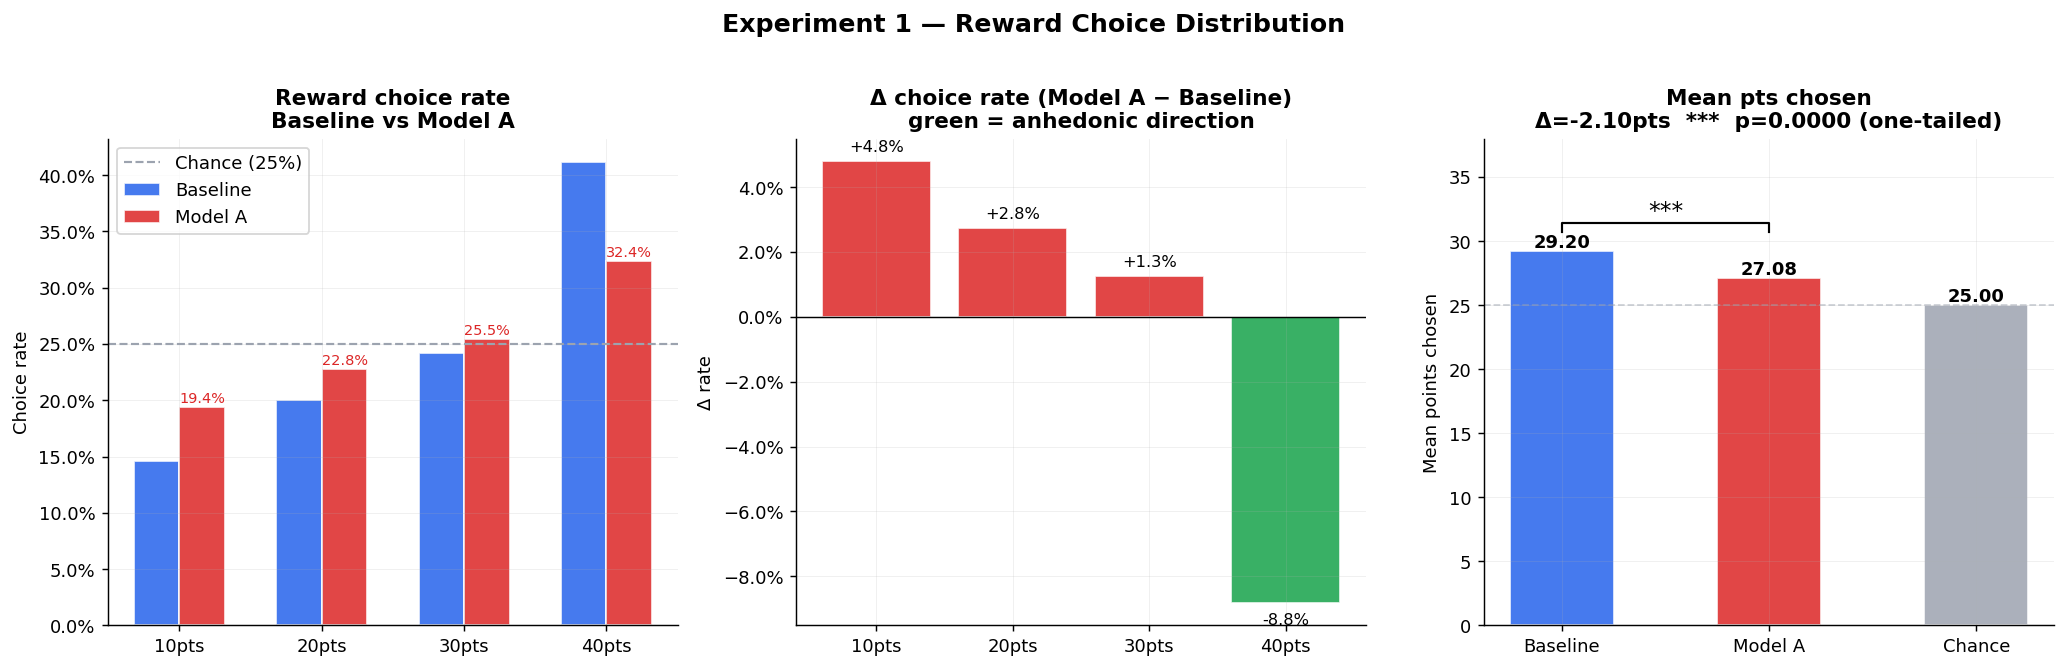

Choice rates:
  10pts  Baseline:0.146  Model A:0.194  Δ:+0.048
  20pts  Baseline:0.200  Model A:0.228  Δ:+0.028
  30pts  Baseline:0.242  Model A:0.255  Δ:+0.013
  40pts  Baseline:0.412  Model A:0.324  Δ:-0.088

Mean pts  Baseline:29.20  Model A:27.08  Δ=-2.10  p=0.0000 ***


In [8]:
vb  = e1_raw[e1_raw['tier']=='baseline']['chosen_reward'].dropna()
va  = e1_raw[e1_raw['tier']=='model_A']['chosen_reward'].dropna()
db  = {r: (vb==r).mean() for r in REWARD_LEVELS}
da  = {r: (va==r).mean() for r in REWARD_LEVELS}
dlt = {r: da[r]-db[r]    for r in REWARD_LEVELS}

x, w = np.arange(4), 0.32
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Grouped bars ───────────────────────────────────────────────────────────
ax = axes[0]
ax.bar(x-w/2, [db[r] for r in REWARD_LEVELS], w, color=BL, alpha=0.85,
       label='Baseline', edgecolor='white')
ax.bar(x+w/2, [da[r] for r in REWARD_LEVELS], w, color=MA, alpha=0.85,
       label='Model A',  edgecolor='white')
ax.axhline(0.25, color=CH, lw=1.2, ls='--', label='Chance (25%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xticks(x); ax.set_xticklabels([f'{r}pts' for r in REWARD_LEVELS])
ax.set_ylabel('Choice rate')
ax.set_title('Reward choice rate\nBaseline vs Model A', fontweight='bold')
ax.legend()
for i, r in enumerate(REWARD_LEVELS):
    ax.text(i+w/2, da[r]+0.004, f'{da[r]:.1%}', ha='center', fontsize=8, color=MA)

# ── Delta bars ─────────────────────────────────────────────────────────────
ax2 = axes[1]
dcols = [GR if dlt[r]<0 else MA for r in REWARD_LEVELS]
ax2.bar(x, [dlt[r] for r in REWARD_LEVELS], color=dcols, alpha=0.85, edgecolor='white')
ax2.axhline(0, color='black', lw=0.8)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.set_xticks(x); ax2.set_xticklabels([f'{r}pts' for r in REWARD_LEVELS])
ax2.set_ylabel('Δ rate')
ax2.set_title('Δ choice rate (Model A − Baseline)\ngreen = anhedonic direction', fontweight='bold')
for i, r in enumerate(REWARD_LEVELS):
    ax2.text(i, dlt[r]+(0.002 if dlt[r]>=0 else -0.003),
             f'{dlt[r]:+.1%}', ha='center',
             va='bottom' if dlt[r]>=0 else 'top', fontsize=9)

# ── Mean pts bar + significance bracket ────────────────────────────────────
ax3 = axes[2]
means = [vb.mean(), va.mean(), CHANCE_MEAN]
bars  = ax3.bar(['Baseline','Model A','Chance'], means,
                color=[BL,MA,CH], alpha=0.85, edgecolor='white', width=0.5)
ax3.axhline(CHANCE_MEAN, color=CH, lw=1, ls='--', alpha=0.5)
ax3.set_ylim(0, 38)
ax3.set_ylabel('Mean points chosen')
for bar, val in zip(bars, means):
    ax3.text(bar.get_x()+bar.get_width()/2, val+0.3,
             f'{val:.2f}', ha='center', fontweight='bold')
add_bracket(ax3, 0, 1, max(means[:2])+1.5, tt_pts['p1'], h=0.7, fs=13)
ax3.set_title(
    f'Mean pts chosen\nΔ={tt_pts["delta"]:+.2f}pts  '
    f'{sig_stars(tt_pts["p1"])}  p={tt_pts["p1"]:.4f} (one-tailed)',
    fontweight='bold')

plt.suptitle('Experiment 1 — Reward Choice Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{EXP1_DIR}/fig_E1_choice_distribution.png', bbox_inches='tight')
plt.show()

print('Choice rates:')
for r in REWARD_LEVELS:
    print(f'  {r:>2}pts  Baseline:{db[r]:.3f}  Model A:{da[r]:.3f}  Δ:{dlt[r]:+.3f}')
print(f'\nMean pts  Baseline:{vb.mean():.2f}  Model A:{va.mean():.2f}  '
      f'Δ={tt_pts["delta"]:+.2f}  p={tt_pts["p1"]:.4f} {sig_stars(tt_pts["p1"])}')

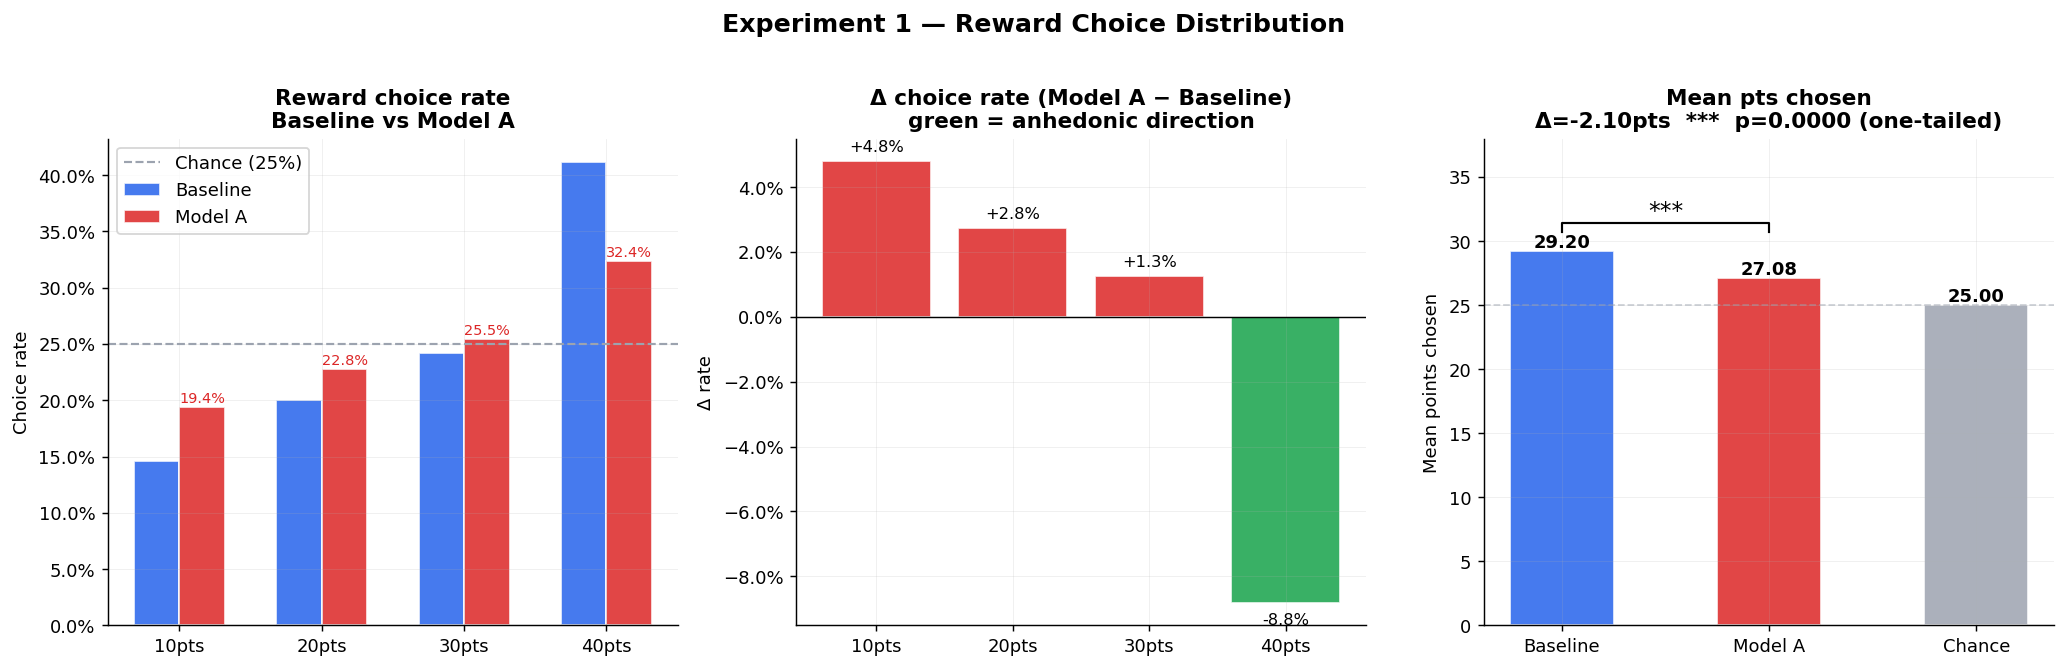

Choice rates:
  10pts  Baseline:0.146  Model A:0.194  Δ:+0.048
  20pts  Baseline:0.200  Model A:0.228  Δ:+0.028
  30pts  Baseline:0.242  Model A:0.255  Δ:+0.013
  40pts  Baseline:0.412  Model A:0.324  Δ:-0.088

Mean pts  Baseline:29.20  Model A:27.08  Δ=-2.10  p=0.0000 ***


In [18]:
vb  = e1_raw[e1_raw['tier']=='baseline']['chosen_reward'].dropna()
va  = e1_raw[e1_raw['tier']=='model_A']['chosen_reward'].dropna()
db  = {r: (vb==r).mean() for r in REWARD_LEVELS}
da  = {r: (va==r).mean() for r in REWARD_LEVELS}
dlt = {r: da[r]-db[r]    for r in REWARD_LEVELS}

x, w = np.arange(4), 0.32
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Grouped bars ───────────────────────────────────────────────────────────
ax = axes[0]
ax.bar(x-w/2, [db[r] for r in REWARD_LEVELS], w, color=BL, alpha=0.85,
       label='Baseline', edgecolor='white')
ax.bar(x+w/2, [da[r] for r in REWARD_LEVELS], w, color=MA, alpha=0.85,
       label='Model A',  edgecolor='white')
ax.axhline(0.25, color=CH, lw=1.2, ls='--', label='Chance (25%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xticks(x); ax.set_xticklabels([f'{r}pts' for r in REWARD_LEVELS])
ax.set_ylabel('Choice rate')
ax.set_title('Reward choice rate\nBaseline vs Model A', fontweight='bold')
ax.legend()
for i, r in enumerate(REWARD_LEVELS):
    ax.text(i+w/2, da[r]+0.004, f'{da[r]:.1%}', ha='center', fontsize=8, color=MA)

# ── Delta bars ─────────────────────────────────────────────────────────────
ax2 = axes[1]
dcols = [GR if dlt[r]<0 else MA for r in REWARD_LEVELS]
ax2.bar(x, [dlt[r] for r in REWARD_LEVELS], color=dcols, alpha=0.85, edgecolor='white')
ax2.axhline(0, color='black', lw=0.8)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.set_xticks(x); ax2.set_xticklabels([f'{r}pts' for r in REWARD_LEVELS])
ax2.set_ylabel('Δ rate')
ax2.set_title('Δ choice rate (Model A − Baseline)\ngreen = anhedonic direction', fontweight='bold')
for i, r in enumerate(REWARD_LEVELS):
    ax2.text(i, dlt[r]+(0.002 if dlt[r]>=0 else -0.003),
             f'{dlt[r]:+.1%}', ha='center',
             va='bottom' if dlt[r]>=0 else 'top', fontsize=9)

# ── Mean pts bar + significance bracket ────────────────────────────────────
ax3 = axes[2]
means = [vb.mean(), va.mean(), CHANCE_MEAN]
bars  = ax3.bar(['Baseline','Model A','Chance'], means,
                color=[BL,MA,CH], alpha=0.85, edgecolor='white', width=0.5)
ax3.axhline(CHANCE_MEAN, color=CH, lw=1, ls='--', alpha=0.5)
ax3.set_ylim(0, 38)
ax3.set_ylabel('Mean points chosen')
for bar, val in zip(bars, means):
    ax3.text(bar.get_x()+bar.get_width()/2, val+0.3,
             f'{val:.2f}', ha='center', fontweight='bold')
add_bracket(ax3, 0, 1, max(means[:2])+1.5, tt_pts['p1'], h=0.7, fs=13)
ax3.set_title(
    f'Mean pts chosen\nΔ={tt_pts["delta"]:+.2f}pts  '
    f'{sig_stars(tt_pts["p1"])}  p={tt_pts["p1"]:.4f} (one-tailed)',
    fontweight='bold')

plt.suptitle('Experiment 1 — Reward Choice Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{EXP1_DIR}/fig_E1_choice_distribution.png', bbox_inches='tight')
plt.show()

print('Choice rates:')
for r in REWARD_LEVELS:
    print(f'  {r:>2}pts  Baseline:{db[r]:.3f}  Model A:{da[r]:.3f}  Δ:{dlt[r]:+.3f}')
print(f'\nMean pts  Baseline:{vb.mean():.2f}  Model A:{va.mean():.2f}  '
      f'Δ={tt_pts["delta"]:+.2f}  p={tt_pts["p1"]:.4f} {sig_stars(tt_pts["p1"])}')

## E1.2 — Per-subject mean pts + error bars (std across K=5 folds)

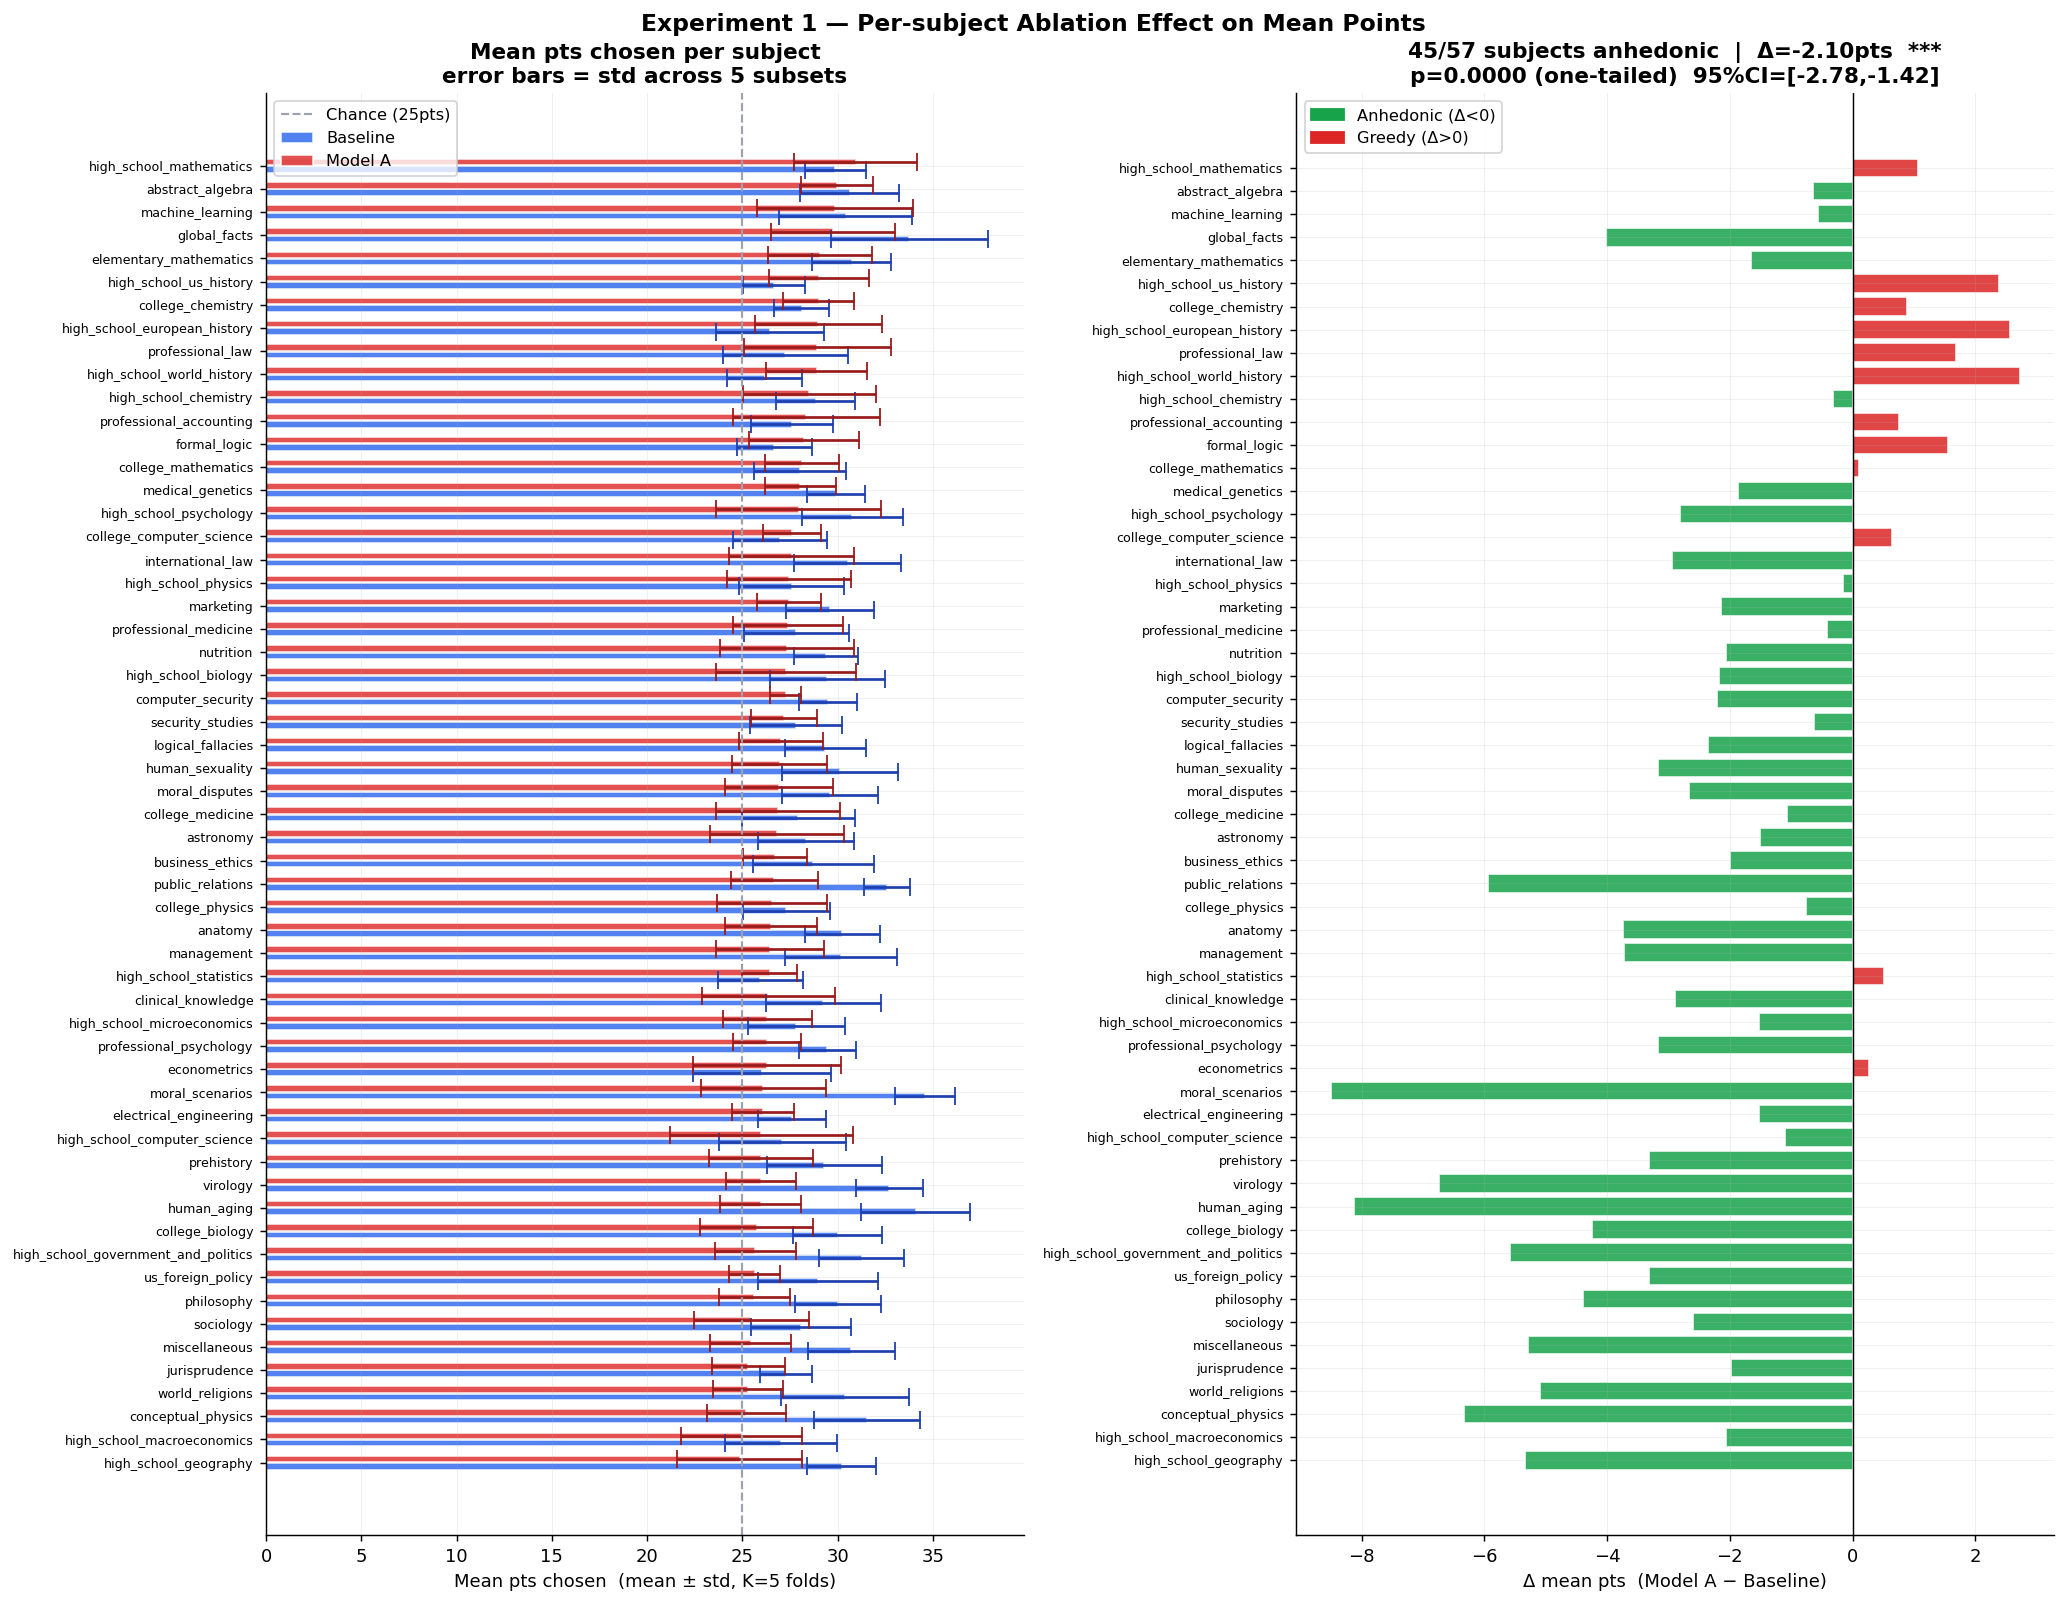

In [9]:
pts = pd.DataFrame({
    'b_mean': e1b.set_index('subject')['mean_pts_mean'],
    'b_std':  e1b.set_index('subject')['mean_pts_std'],
    'a_mean': e1a.set_index('subject')['mean_pts_mean'],
    'a_std':  e1a.set_index('subject')['mean_pts_std'],
}).dropna()
pts['delta'] = pts['a_mean'] - pts['b_mean']
pts = pts.sort_values('a_mean')
y   = np.arange(len(pts))

fig, axes = plt.subplots(1, 2, figsize=(16, max(6, len(pts)*0.22)))

# ── Absolute mean pts ──────────────────────────────────────────────────────
ax = axes[0]
ax.barh(y-0.16, pts['b_mean'], 0.28, xerr=pts['b_std'],
        color=BL, alpha=0.8, label='Baseline', edgecolor='white',
        error_kw={'elinewidth':1.5,'capsize':5,'ecolor':'#1e40af'})
ax.barh(y+0.16, pts['a_mean'], 0.28, xerr=pts['a_std'],
        color=MA, alpha=0.8, label='Model A', edgecolor='white',
        error_kw={'elinewidth':1.5,'capsize':5,'ecolor':'#991b1b'})
ax.axvline(CHANCE_MEAN, color=CH, lw=1.2, ls='--', label='Chance (25pts)')
ax.set_yticks(y); ax.set_yticklabels(pts.index, fontsize=7)
ax.set_xlabel('Mean pts chosen  (mean ± std, K=5 folds)')
ax.set_title('Mean pts chosen per subject\nerror bars = std across 5 subsets', fontweight='bold')
ax.legend(fontsize=9)

# ── Delta ──────────────────────────────────────────────────────────────────
ax2 = axes[1]
dcols = [GR if d<0 else MA for d in pts['delta']]
ax2.barh(y, pts['delta'], color=dcols, alpha=0.85, edgecolor='white')
ax2.axvline(0, color='black', lw=0.8)
ax2.set_yticks(y); ax2.set_yticklabels(pts.index, fontsize=7)
ax2.set_xlabel('Δ mean pts  (Model A − Baseline)')
n_anh = (pts['delta']<0).sum()
ax2.set_title(
    f'{n_anh}/{len(pts)} subjects anhedonic  |  '
    f'Δ={tt_pts["delta"]:+.2f}pts  {sig_stars(tt_pts["p1"])}\n'
    f'p={tt_pts["p1"]:.4f} (one-tailed)  '
    f'95%CI=[{tt_pts["ci"][0]:.2f},{tt_pts["ci"][1]:.2f}]',
    fontweight='bold')
ax2.legend(handles=[
    mpatches.Patch(color=GR, label='Anhedonic (Δ<0)'),
    mpatches.Patch(color=MA, label='Greedy (Δ>0)')], fontsize=9)

plt.suptitle('Experiment 1 — Per-subject Ablation Effect on Mean Points',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{EXP1_DIR}/fig_E1_per_subject.png', bbox_inches='tight')
plt.show()

## E1.3 — Stacked choice distribution per subject

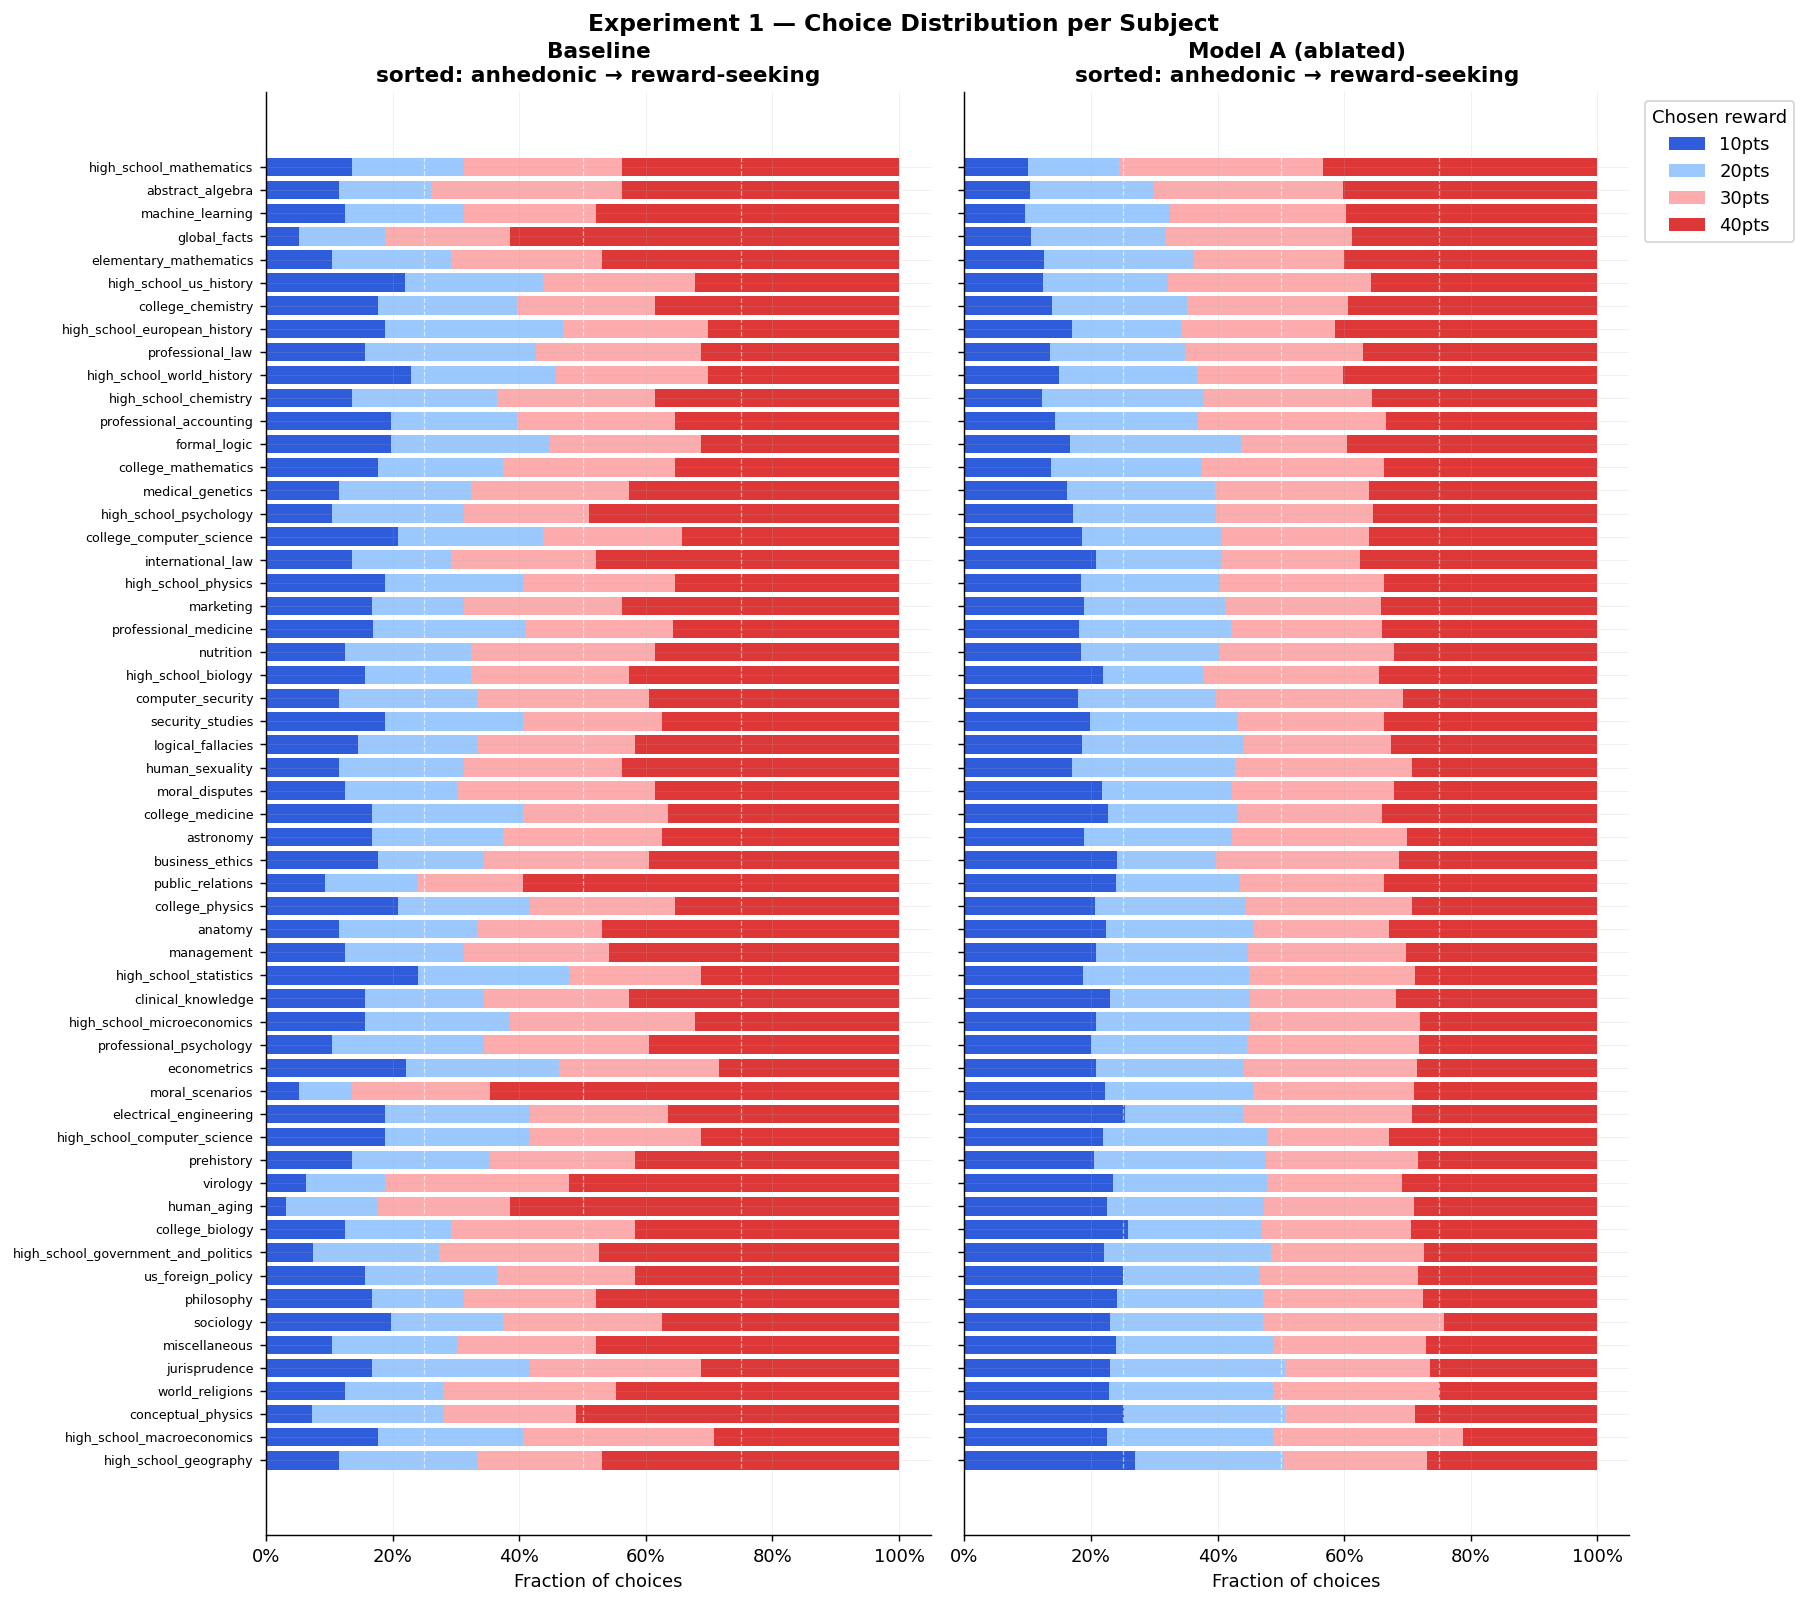

In [10]:
subj_order = pts.index.tolist()
fracs = {}
for tier in ['baseline', 'model_A']:
    fracs[tier] = {}
    for subj, grp in e1_raw[e1_raw['tier']==tier].groupby('subject'):
        v = grp['chosen_reward'].dropna()
        fracs[tier][subj] = {r: (v==r).mean() for r in REWARD_LEVELS}

cmap = {10:C10, 20:C20, 30:C30, 40:C40}
fig, axes = plt.subplots(1, 2, figsize=(14, max(6, len(subj_order)*0.22)), sharey=True)
for ax, tier, title in [(axes[0],'baseline','Baseline'), (axes[1],'model_A','Model A (ablated)')]:
    fdf  = pd.DataFrame(fracs[tier]).T.reindex(subj_order).fillna(0)
    left = np.zeros(len(fdf))
    for r in REWARD_LEVELS:
        ax.barh(fdf.index, fdf[r].values, left=left,
                color=cmap[r], label=f'{r}pts', alpha=0.92)
        left += fdf[r].values
    for v in [0.25, 0.5, 0.75]:
        ax.axvline(v, color='white', lw=0.7, ls='--', alpha=0.6)
    ax.set_xlabel('Fraction of choices')
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_title(f'{title}\nsorted: anhedonic → reward-seeking', fontweight='bold')
    ax.tick_params(axis='y', labelsize=7)
axes[1].legend(title='Chosen reward', bbox_to_anchor=(1.01,1), loc='upper left')
plt.suptitle('Experiment 1 — Choice Distribution per Subject',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{EXP1_DIR}/fig_E1_stacked.png', bbox_inches='tight')
plt.show()

## E1.4 — 40pt choice rate per subject + error bars

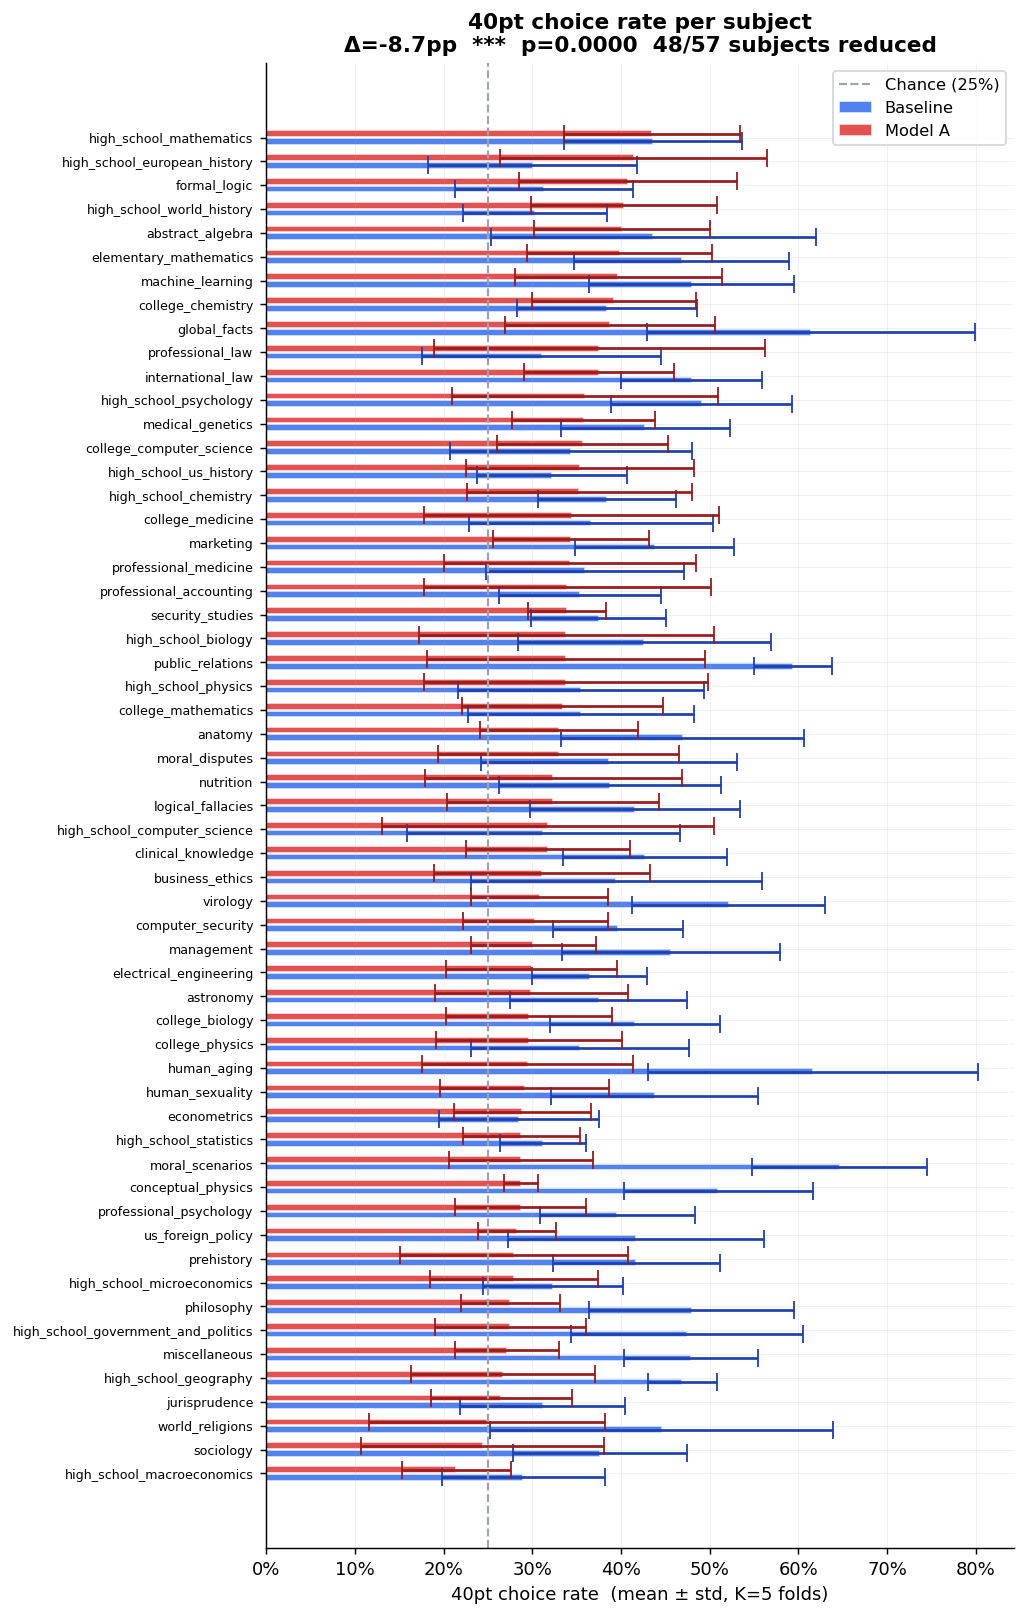

In [11]:
r40b = e1b.set_index('subject')[['rate_40pt_mean','rate_40pt_std']]
r40a = e1a.set_index('subject')[['rate_40pt_mean','rate_40pt_std']]
order40 = r40a.sort_values('rate_40pt_mean').index.tolist()
y = np.arange(len(order40))

fig, ax = plt.subplots(figsize=(8, max(6, len(order40)*0.22)))
ax.barh(y-0.16, r40b.loc[order40,'rate_40pt_mean'], 0.28,
        xerr=r40b.loc[order40,'rate_40pt_std'], color=BL, alpha=0.8,
        label='Baseline', edgecolor='white',
        error_kw={'elinewidth':1.5,'capsize':5,'ecolor':'#1e40af'})
ax.barh(y+0.16, r40a.loc[order40,'rate_40pt_mean'], 0.28,
        xerr=r40a.loc[order40,'rate_40pt_std'], color=MA, alpha=0.8,
        label='Model A', edgecolor='white',
        error_kw={'elinewidth':1.5,'capsize':5,'ecolor':'#991b1b'})
ax.axvline(CHANCE_RS, color=CH, lw=1.2, ls='--', label='Chance (25%)')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_yticks(y); ax.set_yticklabels(order40, fontsize=7)
ax.set_xlabel('40pt choice rate  (mean ± std, K=5 folds)')
n_red = (r40a['rate_40pt_mean'] < r40b['rate_40pt_mean']).sum()
ax.set_title(
    f'40pt choice rate per subject\n'
    f'Δ={tt_40["delta"]*100:+.1f}pp  {sig_stars(tt_40["p1"])}  '
    f'p={tt_40["p1"]:.4f}  {n_red}/{len(r40a)} subjects reduced',
    fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{EXP1_DIR}/fig_E1_40pt_rate.png', bbox_inches='tight')
plt.show()

## E1.5 — Per-subject significance vs chance (BH-corrected t-test)

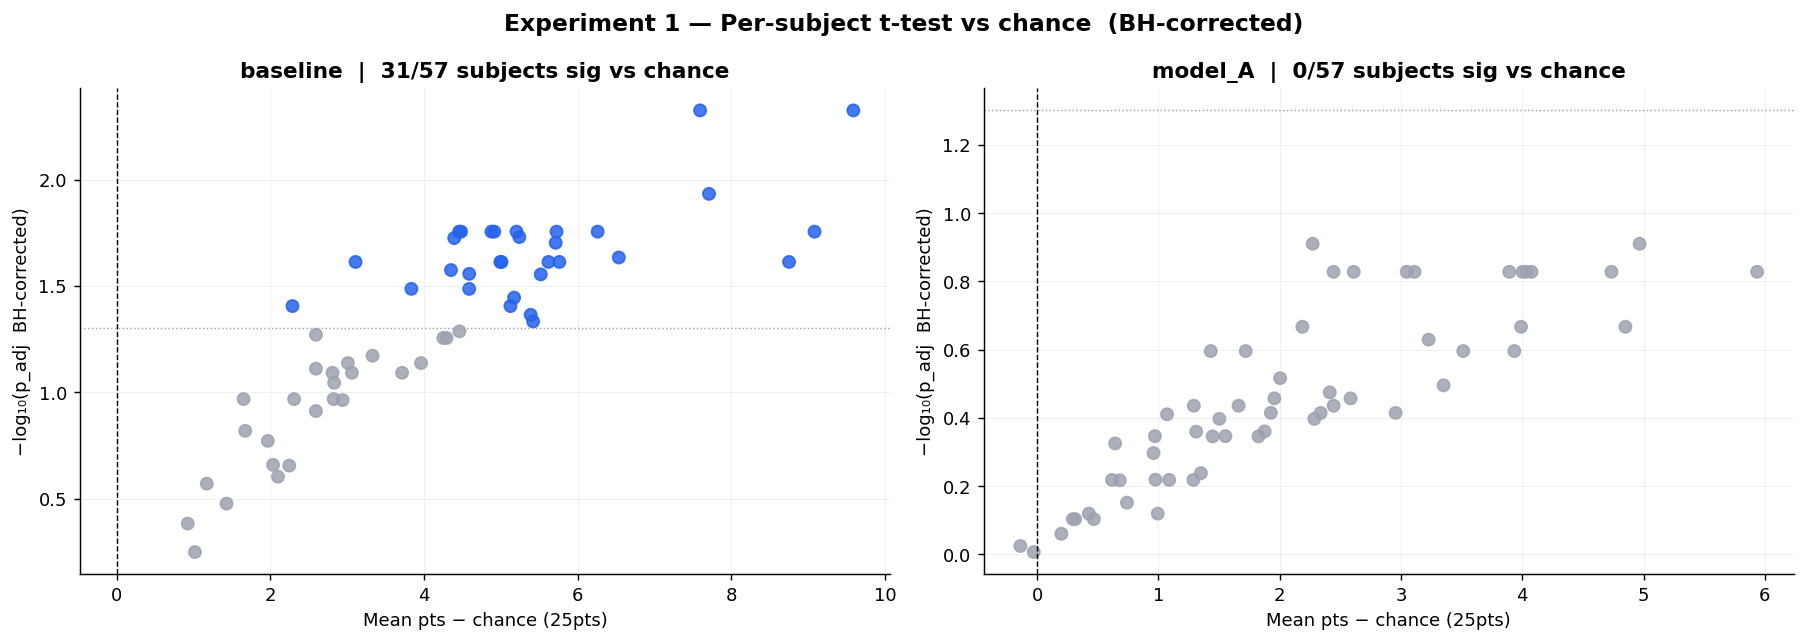

In [12]:
if not e1_subs.empty:
    ttest_rows = []
    for (subj, tier), grp in e1_subs.groupby(['subject','tier']):
        rr = grp['mean_pts'].dropna().values
        if len(rr) >= 2:
            t, p = sp_stats.ttest_1samp(rr, CHANCE_MEAN)
            ttest_rows.append({'subject':subj,'tier':tier,'t':t,'p':p,'mean':rr.mean()})
    tt_df = pd.DataFrame(ttest_rows)
    for tier in ['baseline','model_A']:
        td = tt_df[tt_df['tier']==tier].copy()
        reject, p_adj, _, _ = multipletests(td['p'], method='fdr_bh')
        tt_df.loc[td.index,'p_adj'] = p_adj
        tt_df.loc[td.index,'sig']   = reject

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, tier, color in [(axes[0],'baseline',BL),(axes[1],'model_A',MA)]:
        td    = tt_df[tt_df['tier']==tier]
        pcols = [color if s else CH for s in td['sig']]
        ax.scatter(td['mean']-CHANCE_MEAN, -np.log10(td['p_adj']),
                   c=pcols, s=45, alpha=0.85)
        ax.axvline(0, color='black', lw=0.8, ls='--')
        ax.axhline(-np.log10(0.05), color=CH, lw=0.8, ls=':')
        ax.set_xlabel('Mean pts − chance (25pts)')
        ax.set_ylabel('−log₁₀(p_adj  BH-corrected)')
        n_sig = int(td['sig'].sum())
        ax.set_title(f'{tier}  |  {n_sig}/{len(td)} subjects sig vs chance',
                     fontweight='bold')
    plt.suptitle('Experiment 1 — Per-subject t-test vs chance  (BH-corrected)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{EXP1_DIR}/fig_E1_significance.png', bbox_inches='tight')
    plt.show()

---
# EXPERIMENT 3 — Knowledge Sanity Check

## E3.1 — Robustness accuracy per subject + error bars

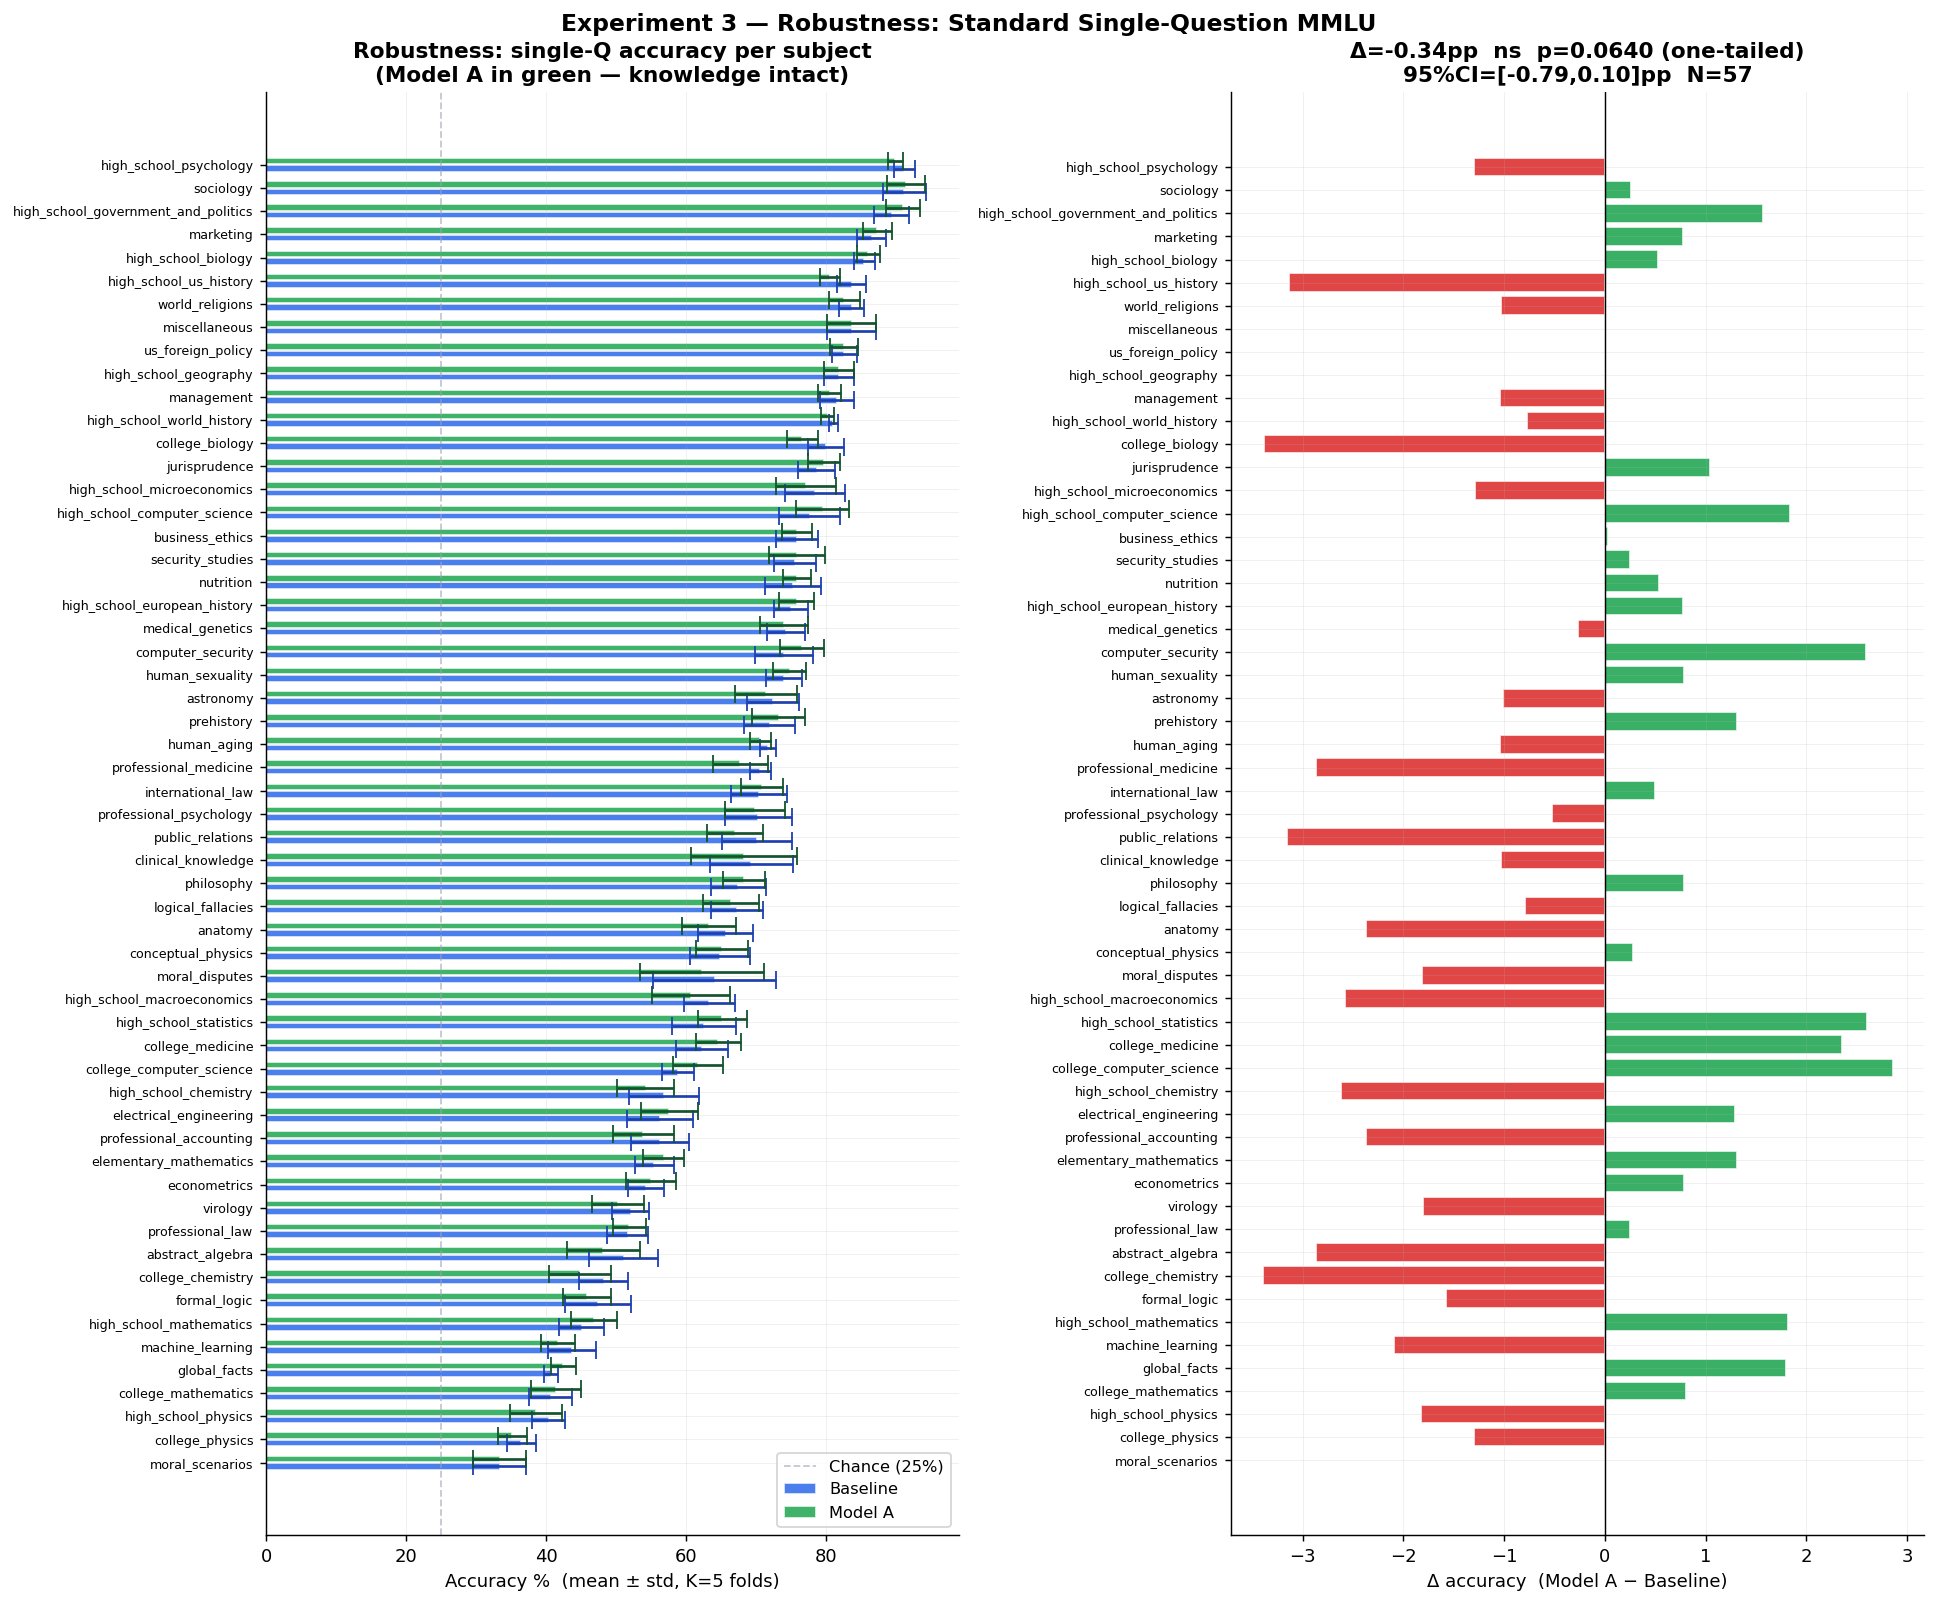

Grand mean  Baseline:66.86%  Model A:66.52%  Δ=-0.34pp  p=0.0640 ns


In [14]:
acc3b = e3b.set_index('subject')[['acc_%_mean','acc_%_std']].copy()
acc3a = e3a.set_index('subject')[['acc_%_mean','acc_%_std']].copy()
c3    = acc3b.index.intersection(acc3a.index)
acc3b, acc3a = acc3b.loc[c3], acc3a.loc[c3]
order3 = acc3b['acc_%_mean'].sort_values().index.tolist()
y = np.arange(len(order3))

fig, axes = plt.subplots(1, 2, figsize=(15, max(6, len(order3)*0.22)))

# ── Accuracy per subject ───────────────────────────────────────────────────
ax = axes[0]
ax.barh(y-0.16, acc3b.loc[order3,'acc_%_mean'], 0.28,
        xerr=acc3b.loc[order3,'acc_%_std'], color=BL, alpha=0.82,
        label='Baseline', edgecolor='white',
        error_kw={'elinewidth':1.5,'capsize':5,'ecolor':'#1e40af'})
ax.barh(y+0.16, acc3a.loc[order3,'acc_%_mean'], 0.28,
        xerr=acc3a.loc[order3,'acc_%_std'], color=GR, alpha=0.82,
        label='Model A', edgecolor='white',
        error_kw={'elinewidth':1.5,'capsize':5,'ecolor':'#14532d'})
ax.axvline(25, color=CH, lw=1, ls='--', alpha=0.6, label='Chance (25%)')
ax.set_yticks(y); ax.set_yticklabels(order3, fontsize=7)
ax.set_xlabel('Accuracy %  (mean ± std, K=5 folds)')
ax.set_title('Robustness: single-Q accuracy per subject\n'
             '(Model A in green — knowledge intact)', fontweight='bold')
ax.legend(fontsize=9)

# ── Delta ──────────────────────────────────────────────────────────────────
ax2 = axes[1]
d3 = acc3a.loc[order3,'acc_%_mean'] - acc3b.loc[order3,'acc_%_mean']
ax2.barh(y, d3, color=[GR if v>=0 else MA for v in d3], alpha=0.85, edgecolor='white')
ax2.axvline(0, color='black', lw=0.8)
ax2.set_yticks(y); ax2.set_yticklabels(order3, fontsize=7)
ax2.set_xlabel('Δ accuracy  (Model A − Baseline)')
ax2.set_title(
    f'Δ={tt_acc3["delta"]:+.2f}pp  {sig_stars(tt_acc3["p1"])}  '
    f'p={tt_acc3["p1"]:.4f} (one-tailed)\n'
    f'95%CI=[{tt_acc3["ci"][0]:.2f},{tt_acc3["ci"][1]:.2f}]pp  N={tt_acc3["n"]}',
    fontweight='bold')

plt.suptitle('Experiment 3 — Robustness: Standard Single-Question MMLU',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{EXP3_DIR}/fig_E3_robustness.png', bbox_inches='tight')
plt.show()
print(f'Grand mean  Baseline:{acc3b["acc_%_mean"].mean():.2f}%  '
      f'Model A:{acc3a["acc_%_mean"].mean():.2f}%  '
      f'Δ={tt_acc3["delta"]:+.2f}pp  p={tt_acc3["p1"]:.4f} {sig_stars(tt_acc3["p1"])}')

## E3.2 — Fold stability (ANOVA across K=5 subsets)

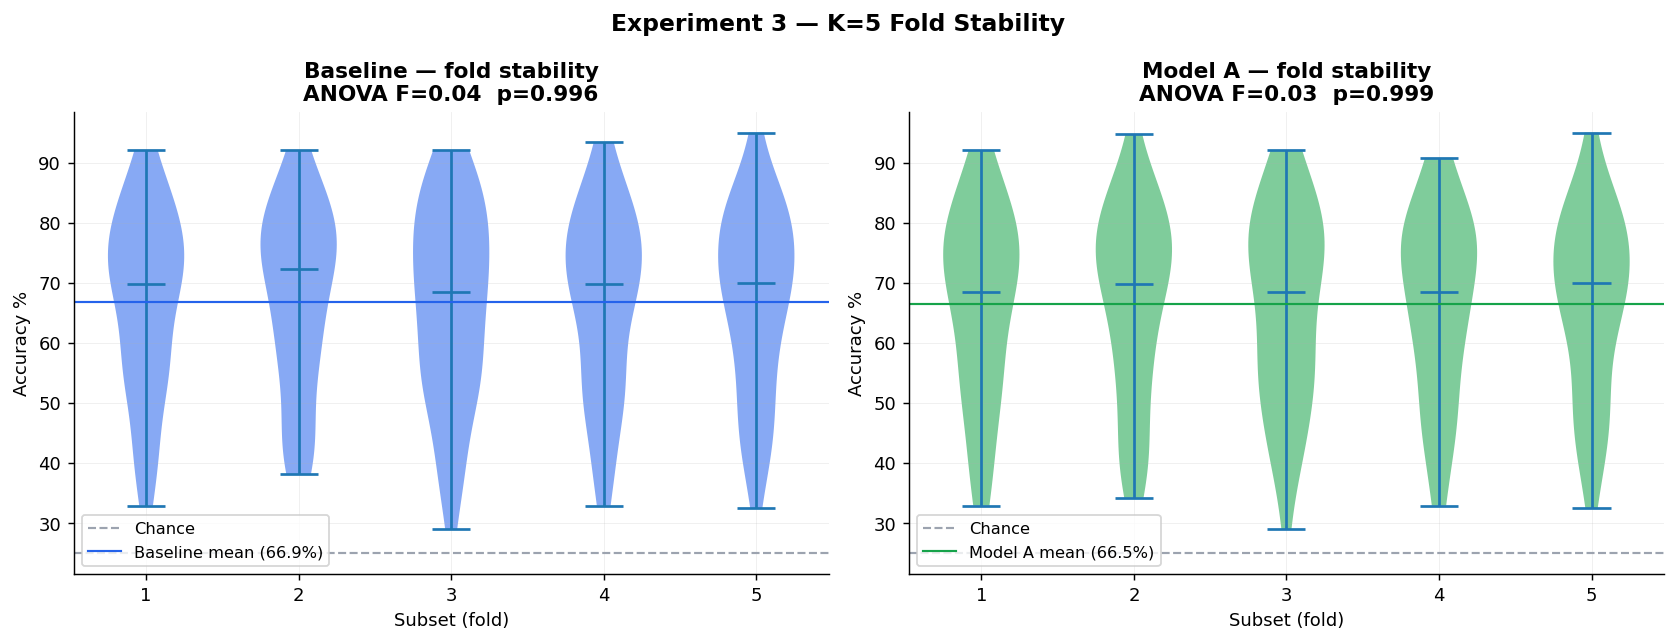

In [15]:
if not e3_subs.empty:
    fold_ids = sorted(e3_subs['subset'].unique())
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, tier, color, label in [
        (axes[0], 'baseline', BL, 'Baseline'),
        (axes[1], 'model_A',  GR, 'Model A'),
    ]:
        td        = e3_subs[e3_subs['tier']==tier]
        fold_data = [td[td['subset']==k]['acc_%'].dropna().values for k in fold_ids]
        vp = ax.violinplot(fold_data, positions=fold_ids, showmedians=True)
        for body in vp['bodies']:
            body.set_facecolor(color); body.set_alpha(0.55)
        gm = td['acc_%'].mean()
        ax.axhline(25,  color=CH,    lw=1.2, ls='--', label='Chance')
        ax.axhline(gm,  color=color, lw=1.2, ls='-',  label=f'{label} mean ({gm:.1f}%)')
        f_stat, p_anova = sp_stats.f_oneway(*fold_data)
        ax.set_xticks(fold_ids); ax.set_xlabel('Subset (fold)')
        ax.set_ylabel('Accuracy %')
        ax.set_title(f'{label} — fold stability\nANOVA F={f_stat:.2f}  p={p_anova:.3f}',
                     fontweight='bold')
        ax.legend(fontsize=9)
    plt.suptitle('Experiment 3 — K=5 Fold Stability',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{EXP3_DIR}/fig_E3_fold_stability.png', bbox_inches='tight')
    plt.show()

---
# COMBINED — Main Figure

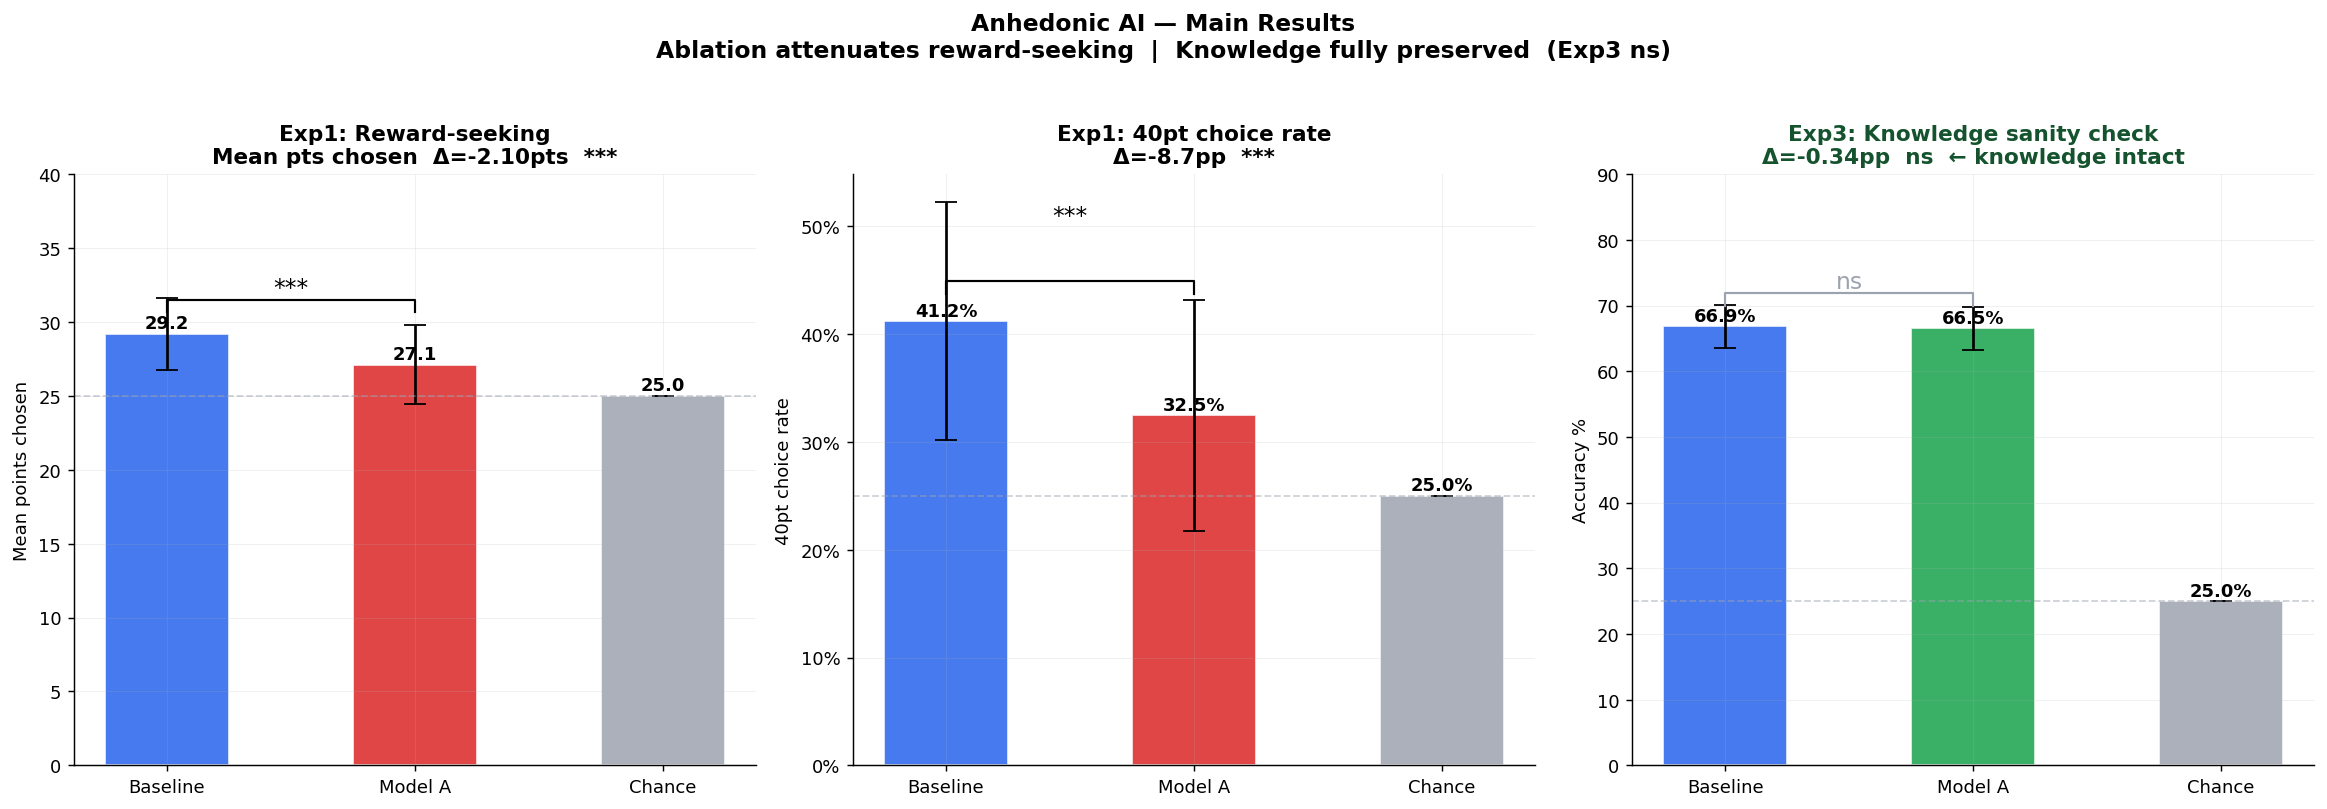

FINAL RESULTS
  Metric                                   Baseline    Model A          Δ         p  Sig
  ────────────────────────────────────────────────────────────────────────
  Exp1  Mean pts chosen  [reward-seeking]      29.20      27.10     -2.10    0.0000  ***
  Exp1  40pt choice rate [reward-seeking]      41.2%      32.5%     -8.7pp    0.0000  ***
  Exp3  Robustness acc   [sanity check]      66.86%     66.52%    -0.34pp    0.0640  ns

  Exp3 ns = knowledge intact. Ablation is reward-specific.


In [ ]:
ش

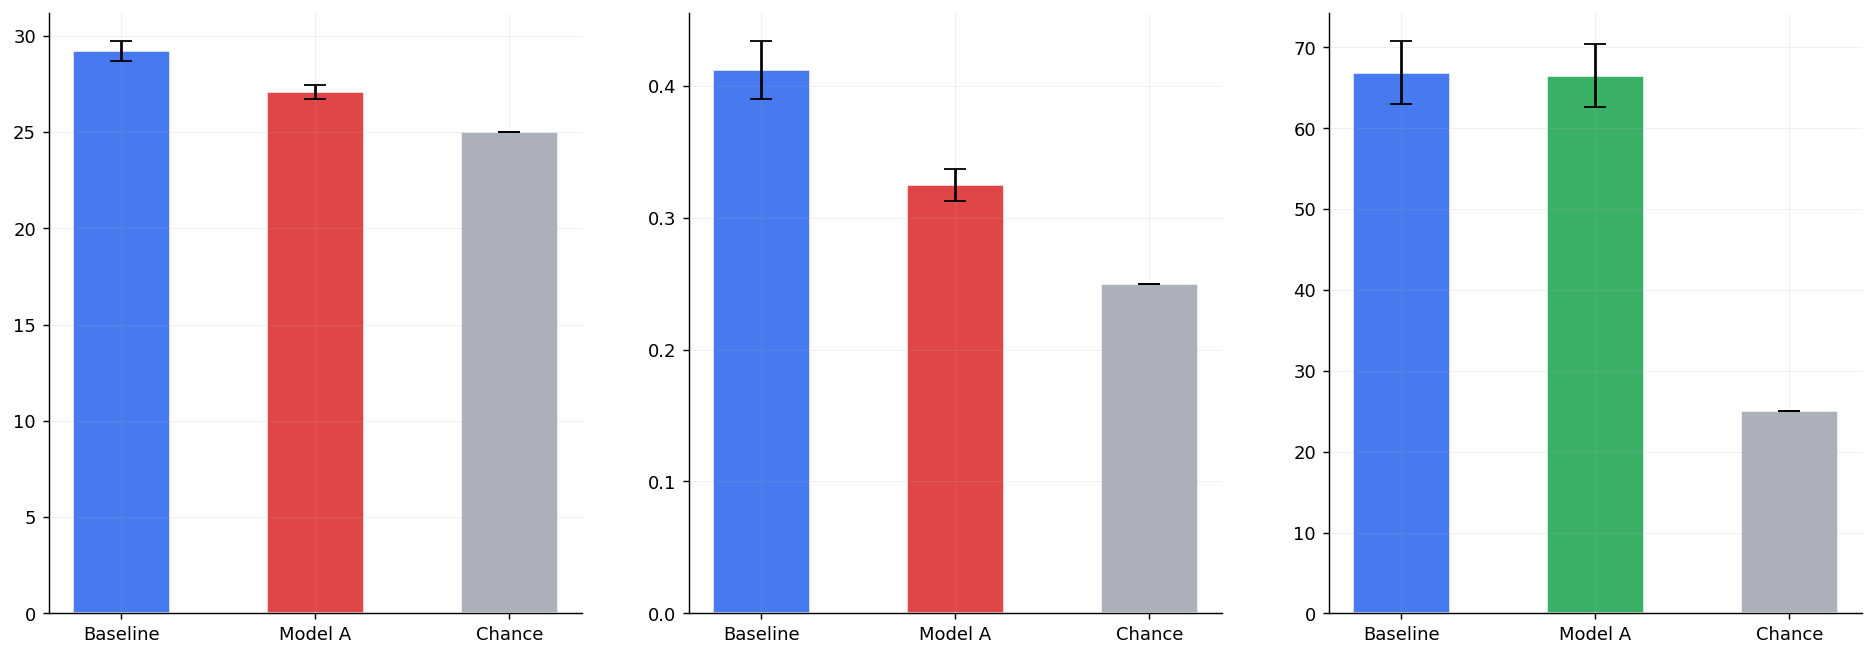

In [ ]:
import scipy.stats as stats
import numpy as np


def get_95ci(data_series):
    # CI = 1.96 * (std / sqrt(n))
    return 1.96 * data_series.std() / np.sqrt(len(data_series))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
cats = ['Baseline', 'Model A', 'Chance']

# ── Panel 1: Mean pts chosen ───────────────────────────────────────────────
ax = axes[0]
mp = [e1b['mean_pts_mean'].mean(), e1a['mean_pts_mean'].mean(), CHANCE_MEAN]


ms = [get_95ci(e1b['mean_pts_mean']), get_95ci(e1a['mean_pts_mean']), 0]

bars = ax.bar(cats, mp, yerr=ms, color=[BL,MA,CH], alpha=0.85, edgecolor='white',
              width=0.5, error_kw={'elinewidth':1.5,'capsize':6})


# ── Panel 2: 40pt choice rate ──────────────────────────────────────────────
ax2 = axes[1]
rp = [e1b['rate_40pt_mean'].mean(), e1a['rate_40pt_mean'].mean(), CHANCE_RS]


rs = [get_95ci(e1b['rate_40pt_mean']), get_95ci(e1a['rate_40pt_mean']), 0]

bars2 = ax2.bar(cats, rp, yerr=rs, color=[BL,MA,CH], alpha=0.85, edgecolor='white',
                width=0.5, error_kw={'elinewidth':1.5,'capsize':6})


# ── Panel 3: Robustness accuracy ───────────────────────────────────────────
ax3 = axes[2]
ap3 = [e3b['acc_%_mean'].mean(), e3a['acc_%_mean'].mean(), 25.0]


as3 = [get_95ci(e3b['acc_%_mean']), get_95ci(e3a['acc_%_mean']), 0]

bars3 = ax3.bar(cats, ap3, yerr=as3, color=[BL,GR,CH], alpha=0.85, edgecolor='white',
                width=0.5, error_kw={'elinewidth':1.5,'capsize':6})
